### Project Overview
For this project, we have three files:

korean_drama.csv: 1752 Korean drama to be explored
review.csv: review given to the drama from users on the website
wiki_actor.csv: information regarding the actors (mainly the drama they were part of and their role)

### Importing the Required Libraries

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast 
from sklearn.model_selection import train_test_split
import networkx as nx
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import string
from collections import Counter

In [76]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\CDMStudent7\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CDMStudent7\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Loading the Drama dataset

In [2]:
df = pd.read_csv('korean_drama.csv')
df.head()

,kdrama_id,drama_name,year,director,screenwriter,country,type,tot_eps,duration,start_dt,end_dt,aired_on,org_net,content_rt,synopsis,rank,pop
0,661d4193916c4e71a2c70473ab11e9e8,Sing My Crush,2023,['So Joon Moon'],NaN,South Korea,Drama,8,1500.0,"Aug 2, 2023","Aug 2, 2023",Wednesday,NaN,Not Yet Rated,Follow the story of acquaintances Ba Ram and H...,1484,2238
1,5ffcbeaa17114714af1959129984274c,D.P. Season 2,2023,NaN,['Kim Bo Tong'],South Korea,Drama,6,3000.0,"Jul 28, 2023","Jul 28, 2023",Friday,Netflix,15+ - Teens 15 or older,This unfolding story ensues when military dese...,164,1084
2,65075cb9c1a54be4a441cee6f16c9fdf,Shadow Detective Season 2,2023,['Han Dong Hwa'],"['Song Jung Woo', 'Hwang Seol Hun']",South Korea,Drama,8,3300.0,2023-07-05,2023-07-26,Wednesday,Disney+ Hulu,15+ - Teens 15 or older,Unfolds the ultimate counterattack of veteran ...,2443,6915
3,df0f0ac4b3ff4b15afa26f5a7a53a328,To Be Honest,2023,NaN,NaN,South Korea,Drama,3,600.0,2023-06-30,2023-07-14,Friday,NaN,Not Yet Rated,Don't you have those days where the whole univ...,49895,99999
4,04c1fe41948e464fb440001831d74d41,Celebrity,2023,['Kim Chul Gyu'],['Kim Yi Young'],South Korea,Drama,12,2700.0,"Jun 30, 2023","Jun 30, 2023",Friday,Netflix,18+ Restricted (violence & profanity),Fame. Money. Power. One young woman fights to ...,826,547


In [11]:
df.describe()

,year,tot_eps,duration,rank,pop
count,1752.000000,1752.000000,1752.000000,1752.000000,1752.000000
mean,2019.006849,18.996005,2145.000000,22247.869292,22153.746575
std,2.317455,25.618394,1522.140765,27688.839480,37776.993814
min,2015.000000,1.000000,60.000000,9.000000,1.000000
25%,2017.000000,8.000000,720.000000,2441.500000,915.750000
50%,2019.000000,12.000000,1800.000000,6265.500000,3698.500000
75%,2021.000000,16.000000,3600.000000,49204.500000,12086.250000
max,2023.000000,150.000000,9180.000000,99999.000000,99999.000000


### Handling the Missing Values in Drama dataset

In [3]:
df['director'].fillna('Unknown', inplace=True)
df['screenwriter'].fillna('Unknown', inplace=True)

# Fill missing 'duration' values with the median of the column
df['duration'].fillna(df['duration'].median(), inplace=True)

In [4]:
df.isnull().sum()

kdrama_id         0
drama_name        0
year              0
director          0
screenwriter      0
country           0
type              0
tot_eps           0
duration          0
start_dt          0
end_dt            0
aired_on        232
org_net         408
content_rt        0
synopsis        168
rank              0
pop               0
dtype: int64

### aired_on Column:

This column appears to have categorical data indicating the day a show aired. If there is no typical pattern or a most common value, you might consider filling this with a placeholder like 'Unknown' or the mode of the column.

In [5]:
if df['aired_on'].mode().empty:
    df['aired_on'].fillna('Unknown', inplace=True)
else:
    df['aired_on'].fillna(df['aired_on'].mode()[0], inplace=True)

### org_net Column:

The org_net column, indicating the original network, also has numerous missing values. Similar to aired_on, you can fill these with 'Unknown' or the mode.

In [6]:
if df['org_net'].mode().empty:
    df['org_net'].fillna('Unknown', inplace=True)
else:
    df['org_net'].fillna(df['org_net'].mode()[0], inplace=True)

### Synopsis Column 
Missing synopses could be filled with a generic text like 'No synopsis available' since it’s text data and may not have a suitable statistical fill.

In [7]:
df['synopsis'].fillna('No synopsis available', inplace=True)
df.isnull().sum()

kdrama_id       0
drama_name      0
year            0
director        0
screenwriter    0
country         0
type            0
tot_eps         0
duration        0
start_dt        0
end_dt          0
aired_on        0
org_net         0
content_rt      0
synopsis        0
rank            0
pop             0
dtype: int64

### Save the cleaned dataframe to a new CSV file

In [8]:
df.to_csv('cleaned_korean_drama.csv', index=False)

### Loding the other Dataset for Cleaning

In [12]:
df_reviews = pd.read_csv('reviews.csv')
df_reviews.describe()

,story_score,acting_cast_score,music_score,rewatch_value_score,overall_score,n_helpful
count,10625.000000,10625.000000,10625.000000,10625.000000,10625.000000,10625.000000
mean,7.501459,8.442635,7.597271,6.170447,7.636988,15.553035
std,2.221619,1.750424,2.188483,3.086057,2.109013,31.726984
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,6.000000,8.000000,6.500000,4.000000,6.500000,2.000000
50%,8.000000,9.000000,8.000000,7.000000,8.000000,6.000000
75%,9.000000,10.000000,9.500000,9.000000,9.500000,15.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,551.000000


In [14]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10625 entries, 0 to 10624
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10625 non-null  object 
 1   title                10625 non-null  object 
 2   story_score          10625 non-null  float64
 3   acting_cast_score    10625 non-null  float64
 4   music_score          10625 non-null  float64
 5   rewatch_value_score  10625 non-null  float64
 6   overall_score        10625 non-null  float64
 7   review_text          10619 non-null  object 
 8   ep_watched           10625 non-null  object 
 9   n_helpful            10625 non-null  int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 830.2+ KB


In [31]:
df_reviews['review_text'].fillna("No review provided", inplace=True)
df_reviews['episodes_watched'] = df_reviews['ep_watched'].apply(lambda x: int(x.split(' ')[0]))
df_reviews['total_episodes'] = df_reviews['ep_watched'].apply(lambda x: int(x.split(' ')[2]) if len(x.split(' ')) > 2 else np.nan)

In [13]:
df_wiki_actors = pd.read_csv('wiki_actors.csv')
df_wiki_actors.describe()

,actor_id,actor_name,drama_name,character_name,role
count,8659,8659,8659,8659,8659
unique,3090,3090,1643,7780,6
top,79fae915-8759-419e-97d8-8e71d7bf986e,Lee Yoo Jin,Check Out the Event,Himself,Main Role
freq,18,18,6,18,5585


In [15]:
df_wiki_actors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8659 entries, 0 to 8658
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   actor_id        8659 non-null   object
 1   actor_name      8659 non-null   object
 2   drama_name      8659 non-null   object
 3   character_name  8659 non-null   object
 4   role            8659 non-null   object
dtypes: object(5)
memory usage: 338.4+ KB


In [32]:
df_wiki_actors['role'] = df_wiki_actors['role'].str.title()  # Capitalizes each word for consistency

### Feature Engineering 

1. Extract Month and Day of the Week from Dates

2. Calculate Duration in Days

3. Categorize Duration into Bins

4. Extract Sentiment from Synopsis

### Ensuring 'start_dt' and 'end_dt' are in datetime format for feature extraction


In [16]:
df = pd.read_csv('cleaned_korean_drama.csv')
df['start_dt'] = pd.to_datetime(df['start_dt'], errors='coerce')
df['end_dt'] = pd.to_datetime(df['end_dt'], errors='coerce')

### 1. Extract month and day of the week from 'start_dt'


In [17]:
df['start_month'] = df['start_dt'].dt.month
df['start_day_of_week'] = df['start_dt'].dt.dayofweek

### 2. Calculate duration in days between 'start_dt' and 'end_dt'


In [18]:
df['duration_days'] = (df['end_dt'] - df['start_dt']).dt.days

### 3. Define bins and labels for 'duration' categorization

In [19]:
bins = [0, 1800, 3600, float('inf')]  # Example bins in seconds
labels = ['short', 'medium', 'long']
df['duration_category'] = pd.cut(df['duration'], bins=bins, labels=labels)

### Save the enhanced dataset with new features


In [21]:
df.to_csv('enhanced_korean_drama.csv', index=False)

In [22]:
df.head()

,kdrama_id,drama_name,year,director,screenwriter,country,type,tot_eps,duration,start_dt,...,aired_on,org_net,content_rt,synopsis,rank,pop,start_month,start_day_of_week,duration_days,duration_category
0,661d4193916c4e71a2c70473ab11e9e8,Sing My Crush,2023,['So Joon Moon'],Unknown,South Korea,Drama,8,1500.0,2023-08-02,...,Wednesday,Naver TV Cast,Not Yet Rated,Follow the story of acquaintances Ba Ram and H...,1484,2238,8.0,2.0,0.0,short
1,5ffcbeaa17114714af1959129984274c,D.P. Season 2,2023,Unknown,['Kim Bo Tong'],South Korea,Drama,6,3000.0,2023-07-28,...,Friday,Netflix,15+ - Teens 15 or older,This unfolding story ensues when military dese...,164,1084,7.0,4.0,0.0,medium
2,65075cb9c1a54be4a441cee6f16c9fdf,Shadow Detective Season 2,2023,['Han Dong Hwa'],"['Song Jung Woo', 'Hwang Seol Hun']",South Korea,Drama,8,3300.0,2023-07-05,...,Wednesday,Disney+ Hulu,15+ - Teens 15 or older,Unfolds the ultimate counterattack of veteran ...,2443,6915,7.0,2.0,21.0,medium
3,df0f0ac4b3ff4b15afa26f5a7a53a328,To Be Honest,2023,Unknown,Unknown,South Korea,Drama,3,600.0,2023-06-30,...,Friday,Naver TV Cast,Not Yet Rated,Don't you have those days where the whole univ...,49895,99999,6.0,4.0,14.0,short
4,04c1fe41948e464fb440001831d74d41,Celebrity,2023,['Kim Chul Gyu'],['Kim Yi Young'],South Korea,Drama,12,2700.0,2023-06-30,...,Friday,Netflix,18+ Restricted (violence & profanity),Fame. Money. Power. One young woman fights to ...,826,547,6.0,4.0,0.0,medium


### Handling NaN Values in Date-Related Features:

In [23]:
# Display rows where 'start_dt' or 'end_dt' is NaT
df[df['start_dt'].isna() | df['end_dt'].isna()]

,kdrama_id,drama_name,year,director,screenwriter,country,type,tot_eps,duration,start_dt,...,aired_on,org_net,content_rt,synopsis,rank,pop,start_month,start_day_of_week,duration_days,duration_category
482,cb1fcbaf4405470487e84f4d11d90055,Girlfriend in The Men's Group,2021,Unknown,Unknown,South Korea,Drama,7,600.0,NaT,...,"Monday, Tuesday",Naver TV Cast,Not Yet Rated,"Wisdom and the Nam Sachin's Su Ju, Ho Tae, Jin...",55505,15555,NaN,NaN,NaN,short
1331,e5ead88b53794fcdbfe3b3db397e4f49,No Bad Days,2017,Unknown,Unknown,South Korea,Drama,10,240.0,NaT,...,"Monday, Tuesday",Naver TV Cast,Not Yet Rated,An ordinary female protagonist in her twenties...,43201,99999,NaN,NaN,NaN,short
1511,763ad7afe7834229840ba31a84f7847f,Romantic Boss,2016,Unknown,Unknown,South Korea,Drama,12,900.0,NaT,...,"Monday, Tuesday",Naver TV Cast,Not Yet Rated,The story of a diverse group of young adult pr...,55258,14549,NaN,NaN,NaN,short


### Review and Validate the Duration Calculation:

In [24]:
# Re-check the calculation for any logical errors
df['duration_days'] = (df['end_dt'] - df['start_dt']).dt.days
df[['start_dt', 'end_dt', 'duration_days']].head()

,start_dt,end_dt,duration_days
0,2023-08-02,2023-08-02,0.0
1,2023-07-28,2023-07-28,0.0
2,2023-07-05,2023-07-26,21.0
3,2023-06-30,2023-07-14,14.0
4,2023-06-30,2023-06-30,0.0


### Enhance Duration Feature:

In [25]:
# Adjusting duration calculation to treat same day as 1 day
df['duration_days'] = (df['end_dt'] - df['start_dt']).dt.days
df['duration_days'] = df['duration_days'].replace(0, 1)  # Replace 0 days with 1 day
df['duration_days'] = df['duration_days'].fillna(0)  # Replace NaT with 0 days if that makes sense for your analysis

### Validate Duration Changes:

In [27]:
df[['start_dt', 'end_dt', 'duration_days']].sample(10)

,start_dt,end_dt,duration_days
646,2020-09-04,2020-09-25,21.0
830,2019-10-13,2019-12-08,56.0
24,2023-05-10,2023-06-14,35.0
1717,2015-04-06,2015-08-21,137.0
469,2021-05-19,2021-06-01,13.0
340,2021-11-30,2021-12-23,23.0
544,2021-02-13,2021-02-20,7.0
45,2023-03-31,2023-05-20,50.0
1623,2015-11-12,2016-01-14,63.0
380,2021-10-19,2021-11-19,31.0


### Further Refinements

Ensure 1-Day Minimum Duration:

Handling NaT Values:

Refining the Replacement Logic:

In [26]:
# Ensure 'start_dt' and 'end_dt' are in datetime format
df['start_dt'] = pd.to_datetime(df['start_dt'], errors='coerce')
df['end_dt'] = pd.to_datetime(df['end_dt'], errors='coerce')

# Recalculate 'duration_days'
df['duration_days'] = (df['end_dt'] - df['start_dt']).dt.days

# Replace 0 days with 1 day
df['duration_days'] = df['duration_days'].replace(0, 1)

# Fill NaN values in 'duration_days' after re-calculating
df['duration_days'] = df['duration_days'].fillna(0)  # Or another placeholder, if more appropriate

# Display the data again to verify the changes
df[['start_dt', 'end_dt', 'duration_days']].sample(10)


,start_dt,end_dt,duration_days
294,2022-01-28,2022-01-28,1.0
732,2020-04-06,2020-04-14,8.0
328,2021-12-11,2022-05-01,141.0
1384,2017-04-21,2017-06-10,50.0
150,2022-09-30,2022-11-05,36.0
480,2021-05-03,2021-06-08,36.0
241,2022-04-26,2022-05-18,22.0
992,2019-02-14,2019-05-01,76.0
1040,2018-12-01,2018-12-08,7.0
149,2022-10-03,2022-12-13,71.0


### Implementing an Imputation Strategy

In [28]:
# Impute missing 'start_dt' and 'end_dt' with the median date, if appropriate
median_start_dt = df['start_dt'].median()
median_end_dt = df['end_dt'].median()

df['start_dt'].fillna(median_start_dt, inplace=True)
df['end_dt'].fillna(median_end_dt, inplace=True)

# Recalculate 'duration_days' after imputation
df['duration_days'] = (df['end_dt'] - df['start_dt']).dt.days
df['duration_days'] = df['duration_days'].replace(0, 1)

# Display the data again to verify the changes
df[['start_dt', 'end_dt', 'duration_days']].sample(10)

,start_dt,end_dt,duration_days
1413,2017-03-01,2017-03-01,1
1564,2016-03-28,2016-06-14,78
179,2022-08-12,2022-08-12,1
490,2021-04-19,2021-04-19,1
564,2020-12-30,2021-02-03,35
280,2022-02-22,2022-03-16,22
65,2023-02-15,2023-03-23,36
348,2021-11-19,2021-11-19,1
1167,2018-05-12,2018-07-07,56
1720,2015-04-02,2015-06-25,84


### Final Cleaned Data

In [34]:
df.to_csv('final_prepped_korean_drama.csv', index=False)
df_reviews.to_csv('clean_reviews.csv', index=False)
df_wiki_actors.to_csv('clean_wiki_actors.csv', index=False)

### Exploratory Data Analysis (EDA)
### Review Dataset

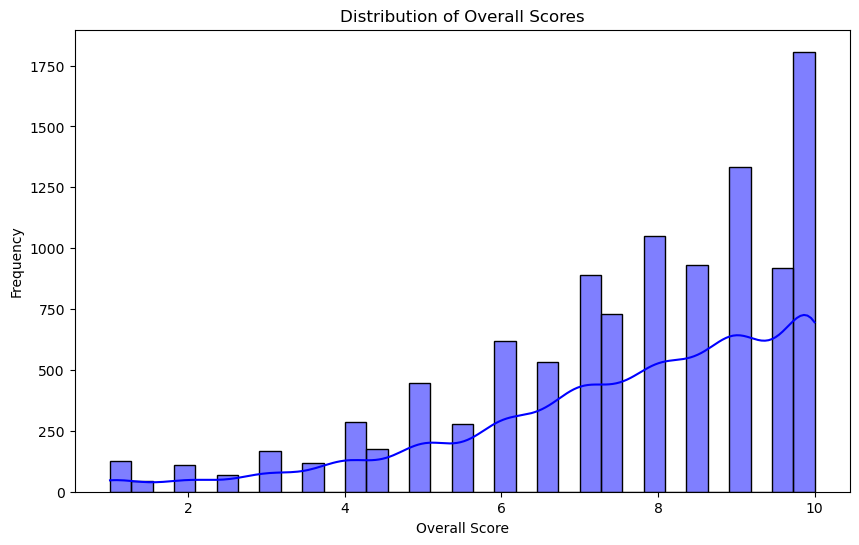

In [36]:
# Plotting score distributions
plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['overall_score'], kde=True, color='blue')
plt.title('Distribution of Overall Scores')
plt.xlabel('Overall Score')
plt.ylabel('Frequency')
plt.show()

### Correlation

C:\Users\CDMStudent7\AppData\Local\Temp\ipykernel_3764\3475497418.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_reviews.corr()


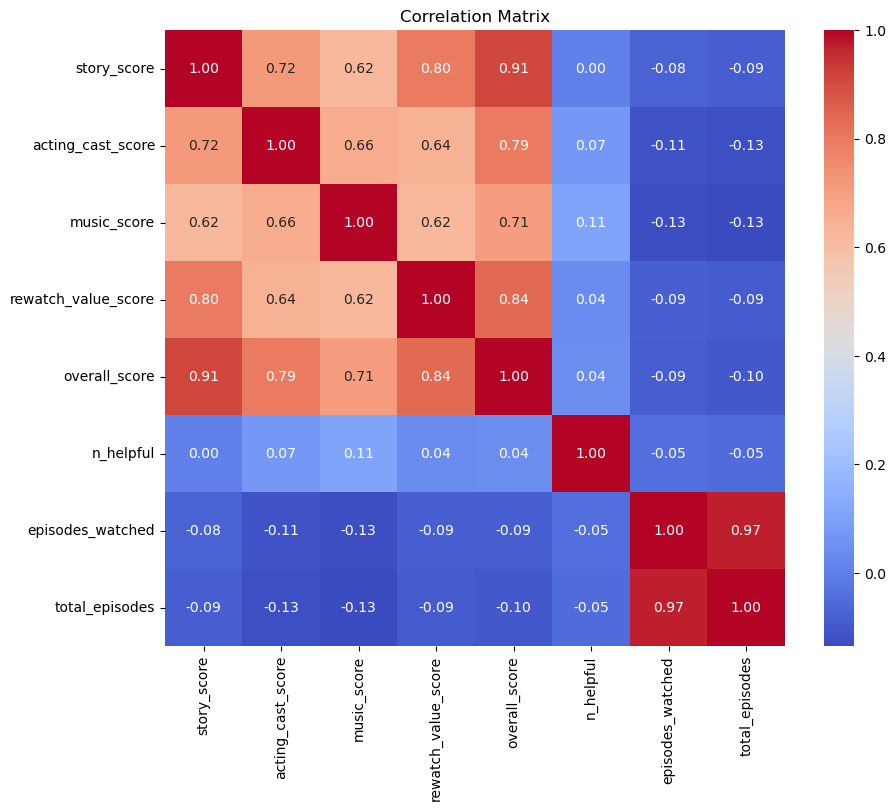

In [38]:
# Compute the correlation matrix
correlation_matrix = df_reviews.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Actors Dataset

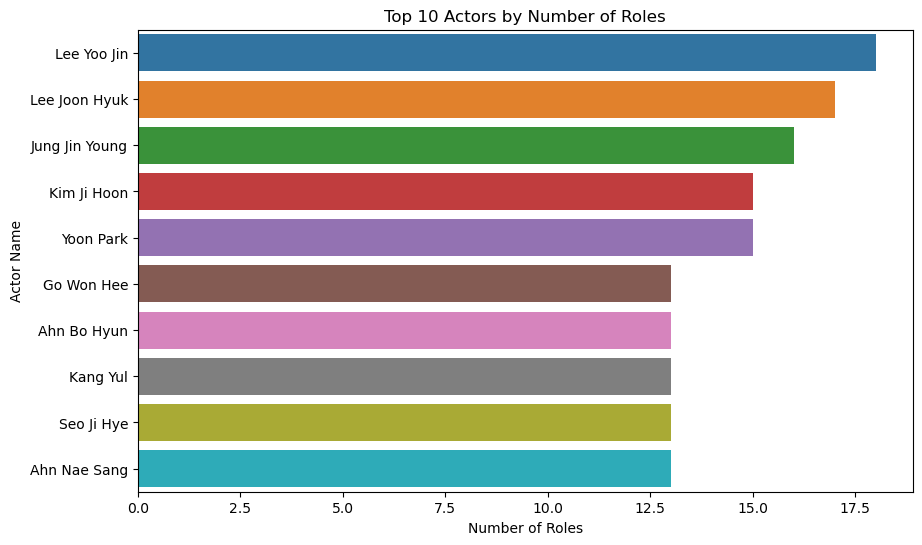

In [39]:
# Actor roles frequency
plt.figure(figsize=(10, 6))
sns.countplot(y=df_wiki_actors['actor_name'], order=pd.value_counts(df_wiki_actors['actor_name']).iloc[:10].index)
plt.title('Top 10 Actors by Number of Roles')
plt.xlabel('Number of Roles')
plt.ylabel('Actor Name')
plt.show()

### Dramas dataset

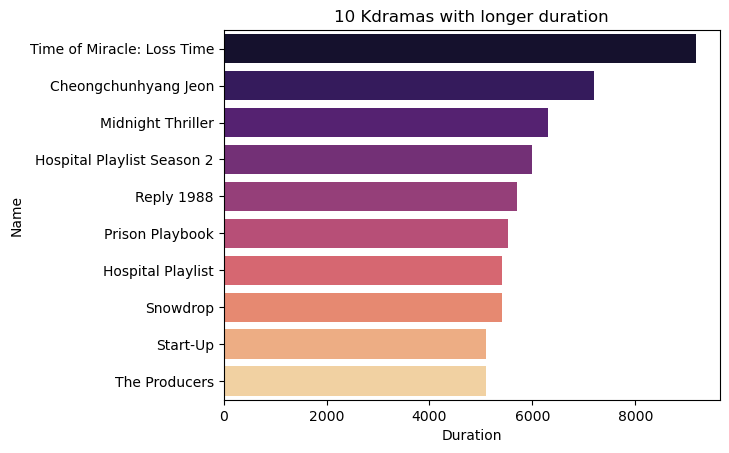

In [40]:
drama_sorted= df.sort_values("duration", ascending= False)
drama10= drama_sorted.iloc[0:10]
sns.barplot(data= drama10, x="duration", y= "drama_name", palette= "magma")

plt.title("10 Kdramas with longer duration")
plt.ylabel("Name")
plt.xlabel("Duration")
plt.show()

### Correlation

C:\Users\CDMStudent7\AppData\Local\Temp\ipykernel_3764\3379428330.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


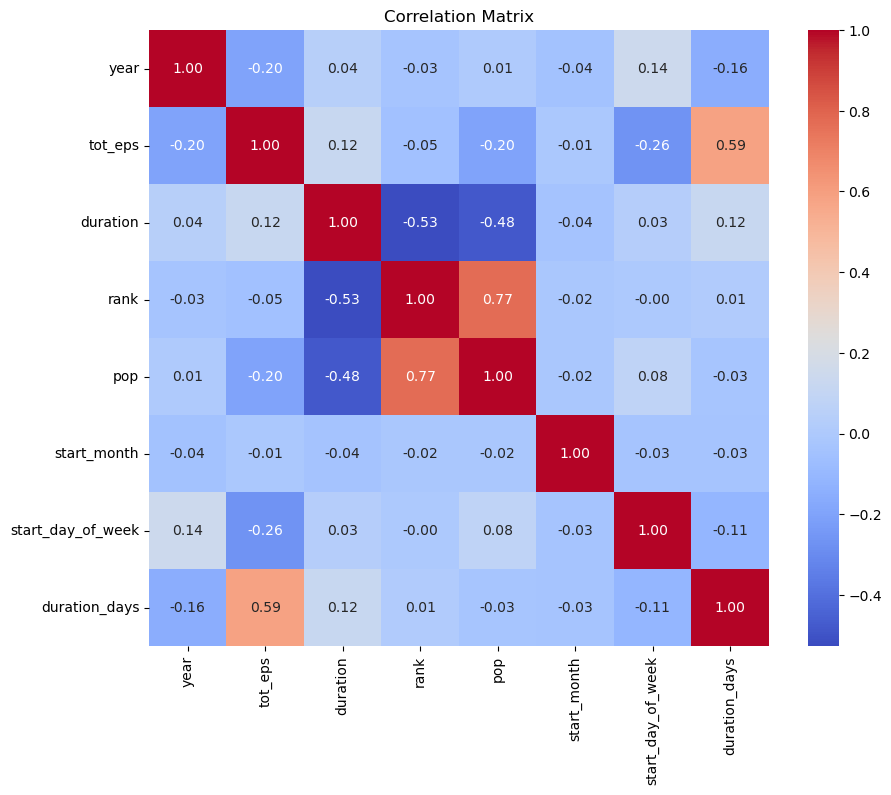

In [42]:
# Compute the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Merge the Datasets

In [44]:
df_wiki_actors['drama_name'] = df_wiki_actors['drama_name'].str.strip().str.lower()
df_reviews['title'] = df_reviews['title'].str.strip().str.lower()

# Merge the datasets on drama name
df_merged = pd.merge(df_wiki_actors, df_reviews, left_on='drama_name', right_on='title', how='inner')

### Analyze the Merged Data

With the merged data, we can now perform various analysis such as identifying the top-rated actors based on the reviews of the dramas they appeared in.

In [45]:
# Calculate average scores and count reviews for each actor
actor_scores = df_merged.groupby('actor_name').agg({
    'overall_score': 'mean',
    'user_id': 'count'  # counting the number of reviews per actor
}).rename(columns={'user_id': 'review_count'}).reset_index()

# Sort actors by highest average score and number of reviews
top_actors = actor_scores.sort_values(by=['overall_score', 'review_count'], ascending=False)

### Plot the Results

Use visualization to display the top actors or to show trends over time.

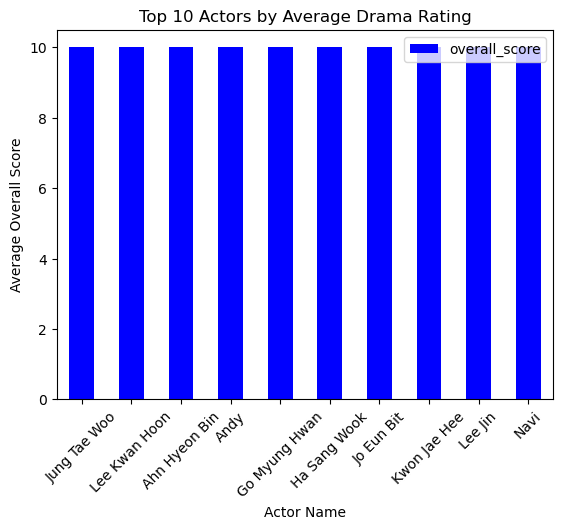

In [39]:
import matplotlib.pyplot as plt

# Top 10 actors by overall score
top_actors.head(10).plot(kind='bar', x='actor_name', y='overall_score', color='blue')
plt.title('Top 10 Actors by Average Drama Rating')
plt.ylabel('Average Overall Score')
plt.xlabel('Actor Name')
plt.xticks(rotation=45)
plt.show()

In [48]:
role_impact = df_merged.groupby(['actor_name', 'role']).agg({
    'overall_score': 'mean',  # Mean of overall scores
}).assign(review_count=lambda x: x.groupby(['actor_name', 'role']).size()).reset_index()


### Visualize the Results

C:\Users\CDMStudent7\AppData\Local\Temp\ipykernel_3764\663721262.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=top_actors, x='overall_score', y='actor_name', hue='role', ci=None)


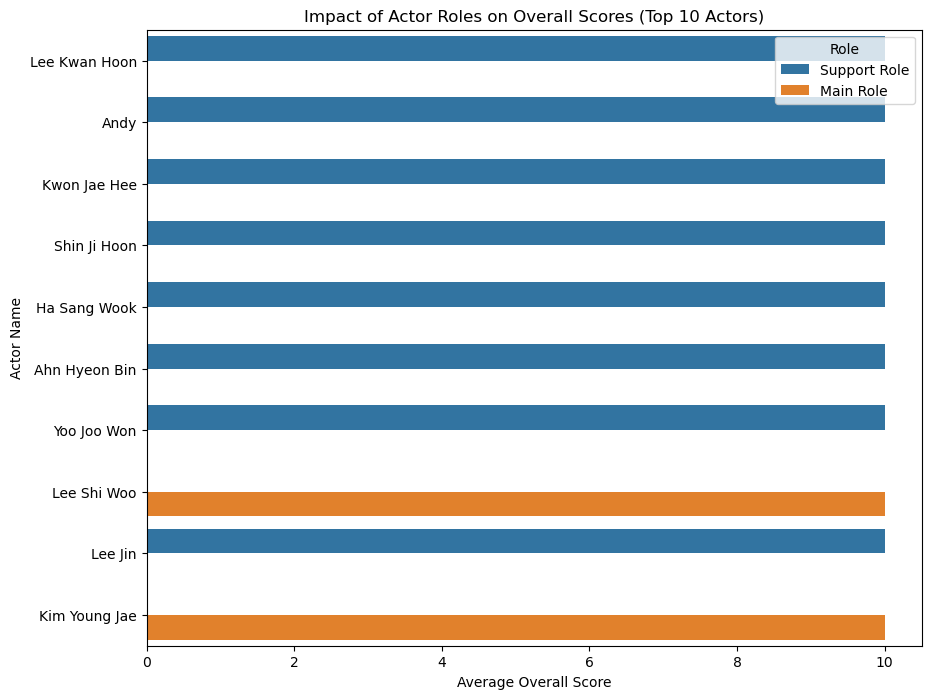

In [49]:
# Sort the dataset by overall_score to get the top 10 actors
top_actors = role_impact.sort_values(by='overall_score', ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_actors, x='overall_score', y='actor_name', hue='role', ci=None)
plt.title('Impact of Actor Roles on Overall Scores (Top 10 Actors)')
plt.xlabel('Average Overall Score')
plt.ylabel('Actor Name')
plt.legend(title='Role')
plt.show()

### Skewness

C:\Users\CDMStudent7\AppData\Local\Temp\ipykernel_3764\930911026.py:2: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  skewness = df_reviews.skew()


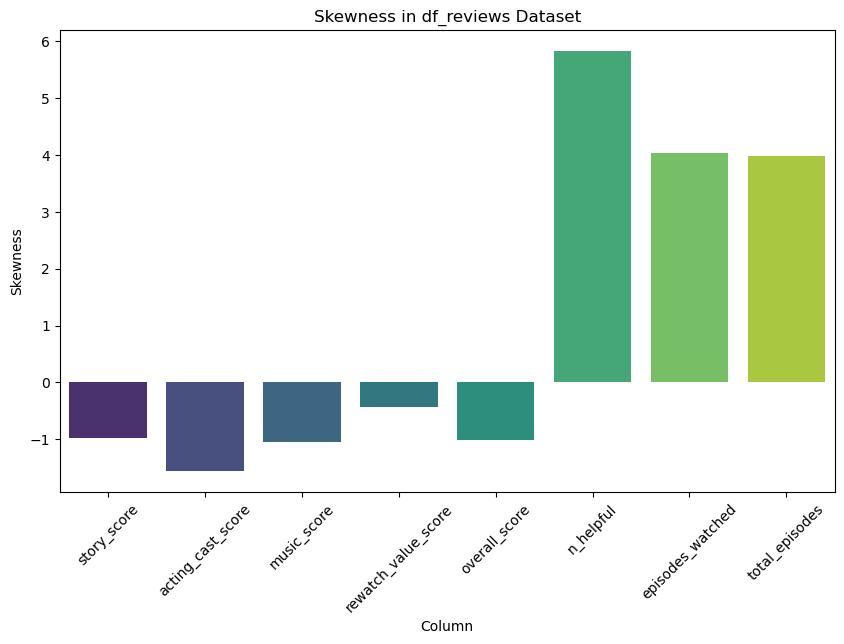

In [50]:
# Calculate skewness for each numerical column
skewness = df_reviews.skew()

# Plotting skewness
plt.figure(figsize=(10, 6))
sns.barplot(x=skewness.index, y=skewness.values, palette='viridis')
plt.title('Skewness in df_reviews Dataset')
plt.xlabel('Column')
plt.ylabel('Skewness')
plt.xticks(rotation=45)
plt.show()

C:\Users\CDMStudent7\AppData\Local\Temp\ipykernel_3764\1775732374.py:2: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  skewness = df.skew()


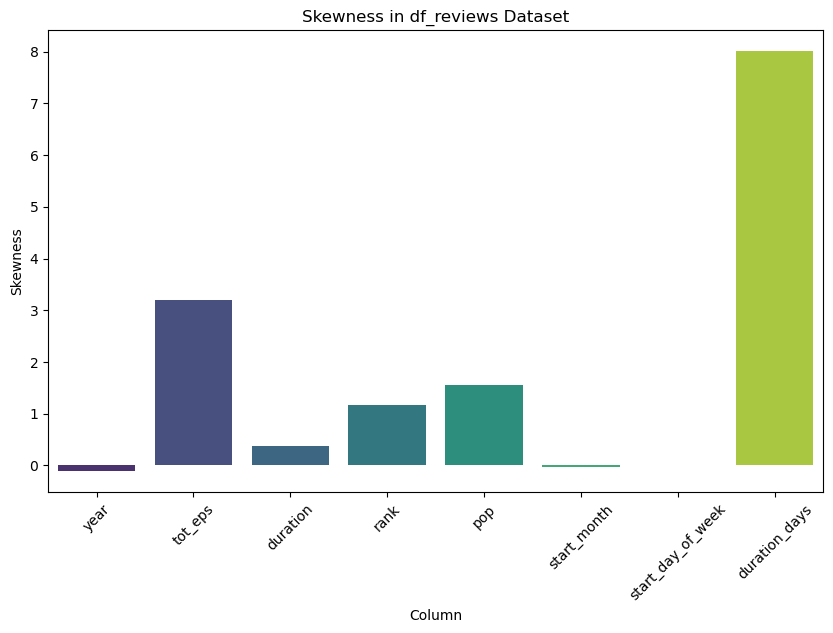

In [51]:
# Calculate skewness for each numerical column
skewness = df.skew()

# Plotting skewness
plt.figure(figsize=(10, 6))
sns.barplot(x=skewness.index, y=skewness.values, palette='viridis')
plt.title('Skewness in df_reviews Dataset')
plt.xlabel('Column')
plt.ylabel('Skewness')
plt.xticks(rotation=45)
plt.show()

### Network Analysis of Actors 
### Creating and Visualizing Network Graph

Number of nodes: 21
Number of edges: 23


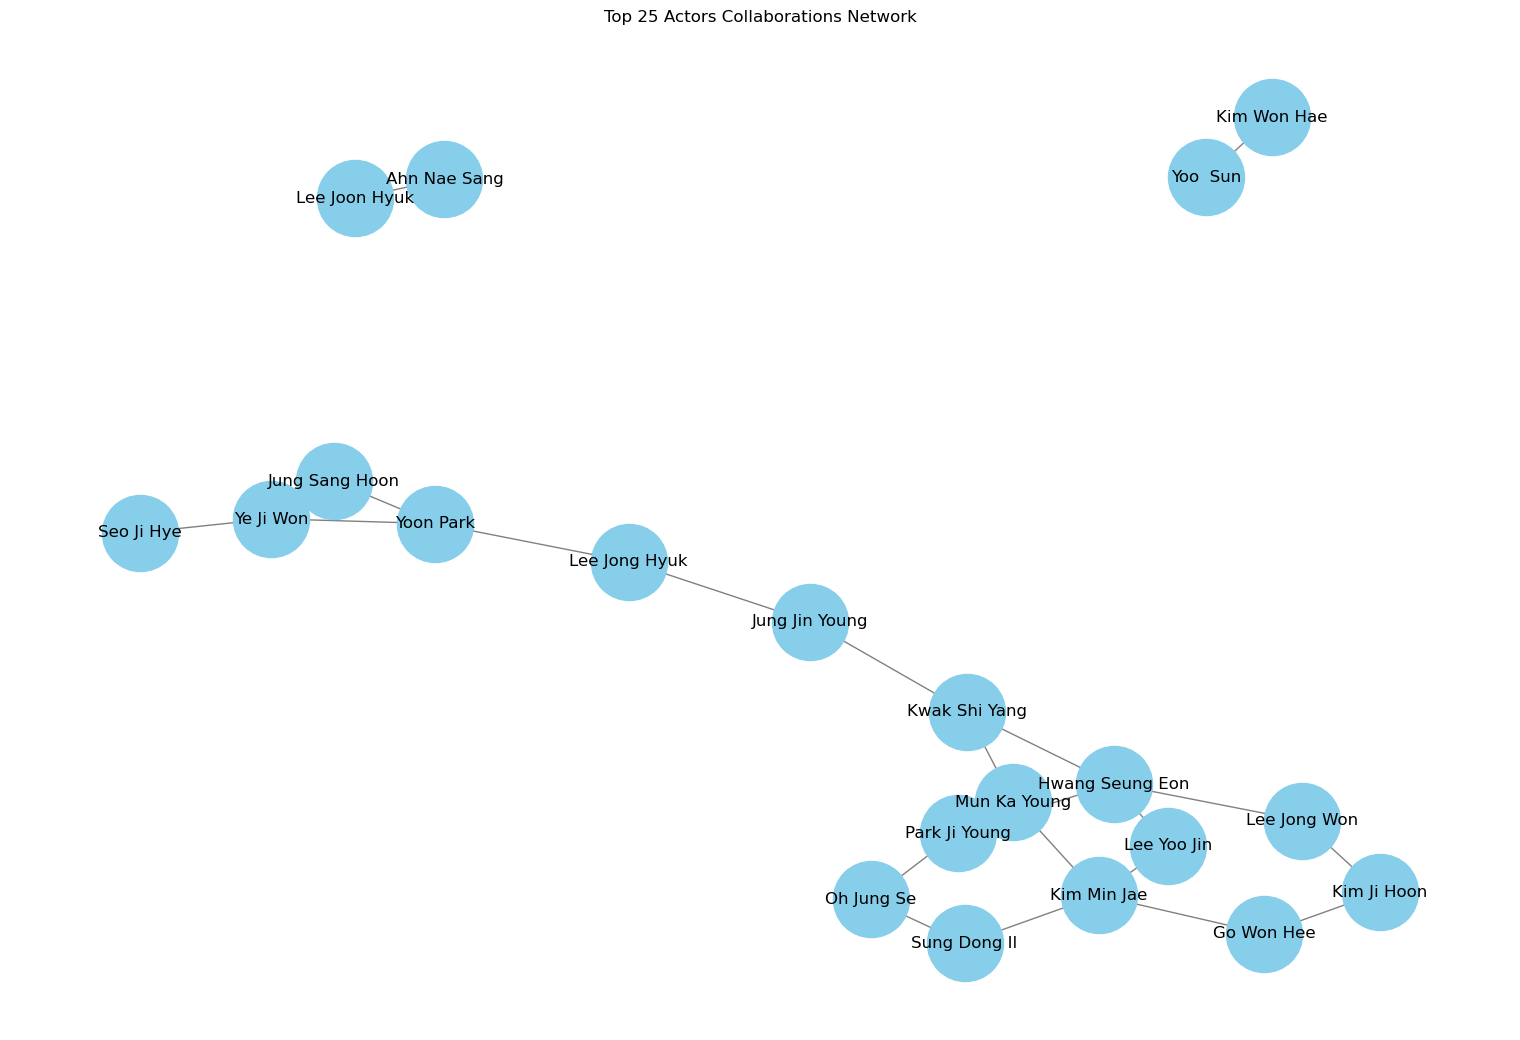

In [64]:
# Create a network graph
G = nx.Graph()

# Count collaborations for each actor
actor_collaborations = {}
for i in range(len(df_wiki_actors)):
    actor = df_wiki_actors['actor_name'][i]
    drama = df_wiki_actors['drama_name'][i]
    
    if actor not in actor_collaborations:
        actor_collaborations[actor] = set()
    
    actor_collaborations[actor].add(drama)

# Identify top 25 actors with most collaborations
top_actors = sorted(actor_collaborations, key=lambda x: len(actor_collaborations[x]), reverse=True)[:25]

# Add edges between top 10 actors who have worked together
for i in range(len(df_wiki_actors)):
    actor1 = df_wiki_actors['actor_name'][i]
    drama1 = df_wiki_actors['drama_name'][i]
    
    if actor1 in top_actors:
        for j in range(i + 1, len(df_wiki_actors)):
            actor2 = df_wiki_actors['actor_name'][j]
            drama2 = df_wiki_actors['drama_name'][j]
            
            if actor2 in top_actors and drama1 == drama2:
                G.add_edge(actor1, actor2, drama=drama1)

# Print basic information about the graph
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Visualize the network graph
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, seed=42) 
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, edge_color='gray', linewidths=1, font_size=12)

plt.title('Top 25 Actors Collaborations Network')
plt.show()

### Sentiment Analysis with BERT using Hugging Face Transformers
We perform sentiment analysis on a dataset of reviews using BERT (Bidirectional Encoder Representations from Transformers) from Hugging Face's Transformers library. BERT is a state-of-the-art language model that excels in understanding context and semantics in natural language text.

In [65]:
review = pd.read_csv("clean_reviews.csv")

In [66]:
# Define sentiment labels based on overall_score
def label_sentiment(overall_score):
    if overall_score >= 7:
        return 2  # Positive
    elif overall_score >= 4:
        return 1  # Neutral
    else:
        return 0  # Negative

review['sentiment'] = review['overall_score'].apply(label_sentiment)

# Reduce the dataset size for faster training (optional)
review = review.sample(frac=0.1, random_state=42)

# Split the data into training and testing sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    review['review_text'].tolist(), 
    review['sentiment'].tolist(), 
    test_size=0.2, 
    random_state=42
)

# Load the tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# Create a custom dataset class
class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
        item = {key: val.squeeze() for key, val in encoding.items()}
        item['labels'] = torch.tensor(label)
        return item

# Create dataset objects
train_dataset = ReviewDataset(train_texts, train_labels)
test_dataset = ReviewDataset(test_texts, test_labels)

# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,  # Reduce the number of epochs
    per_device_train_batch_size=16,  # Increase the batch size
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch"
)

# Create a Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Fine-tune the model
trainer.train()

# Make predictions on the test set
predictions = trainer.predict(test_dataset)
preds = torch.argmax(torch.tensor(predictions.predictions), dim=1)

# Calculate the accuracy
accuracy = accuracy_score(test_labels, preds.numpy())
print(f'Accuracy: {accuracy}')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.850900,0.771026


Accuracy: 0.704225352112676


In [67]:
# Save the sentiments as new columns in a new CSV file
review['predicted_sentiment'] = trainer.predict(ReviewDataset(review['review_text'].tolist(), review['sentiment'].tolist())).predictions.argmax(axis=1)

# Select the required columns
review[['title', 'overall_score', 'review_text', 'predicted_sentiment']].to_csv('reviews_with_predicted_sentiments.csv', index=False)

### Recommendation system

In [123]:
import pandas as pd
from textblob import TextBlob
import nltk
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

In [126]:
# Downloading necessary NLTK corpora
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\CDMStudent7\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\CDMStudent7\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [127]:
# Loading the datasets
df_recommendations = pd.read_csv('clean_recommendations.csv')
df_reviews = pd.read_csv('clean_reviews.csv')

In [128]:
# Normalizing the drama names
df_recommendations['kdrama_name'] = df_recommendations['kdrama_name'].str.strip().str.lower()
df_reviews['title'] = df_reviews['title'].str.strip().str.lower()

In [129]:
# Counting recommendations frequency
recommendation_counts = Counter([drama for sublist in df_recommendations['recommendations'] for drama in sublist])
most_common_recommendations = recommendation_counts.most_common(10)

In [130]:
# Displaying most common recommendations
print("Most Common Recommendations:", most_common_recommendations)

Most Common Recommendations: [(' ', 15597), ("'", 11933), ('e', 9843), ('o', 7919), ('a', 5672), ('n', 5588), ('r', 4977), ('i', 4964), ('t', 4584), (',', 4547)]
